In [15]:
# Cell 1 — Imports
from io import BytesIO
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, mean_squared_error, structural_similarity
import numpy as np

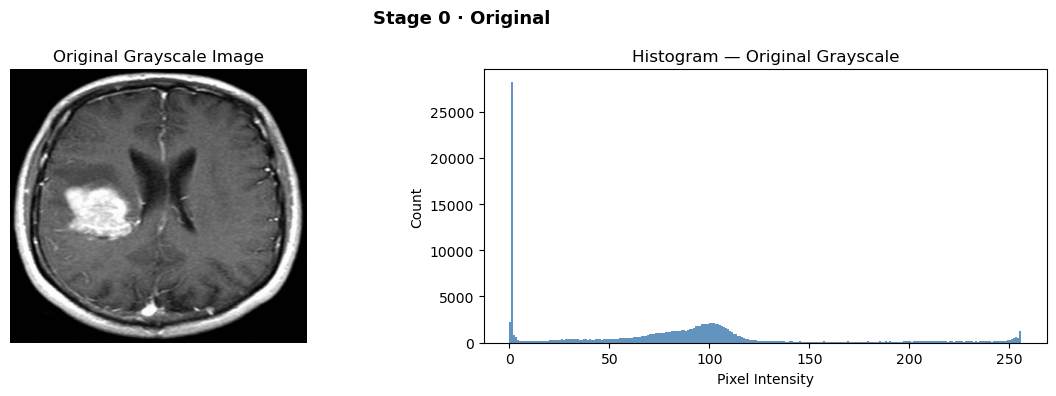

Shape : (369, 400)  |  dtype : uint8  |  range : [0, 255]


In [16]:
# Cell 2 — Load Image (for true grayscale images)
IMAGE_PATH = "./test_images/yes/Y11.jpg"

# Load directly as grayscale
img_gray_pil = Image.open(IMAGE_PATH).convert("L")  # "L" = luminance (grayscale)
img_arr = np.array(img_gray_pil, dtype=np.float32) / 255.0
img_u8 = (img_arr * 255).astype(np.uint8)
gray = img_u8  # already grayscale

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_u8, cmap='gray')  # use colormap!
axes[0].set_title("Original Grayscale Image", fontsize=12)
axes[0].axis("off")
axes[1].hist(gray.ravel(), bins=256, range=(0,256), color="steelblue", alpha=0.85)
axes[1].set_title("Histogram — Original Grayscale")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Count")
plt.suptitle("Stage 0 · Original", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("original_with_histogram.png", dpi=300, bbox_inches='tight')

plt.show()
print(f"Shape : {img_u8.shape}  |  dtype : {img_u8.dtype}  |  range : [{img_u8.min()}, {img_u8.max()}]")

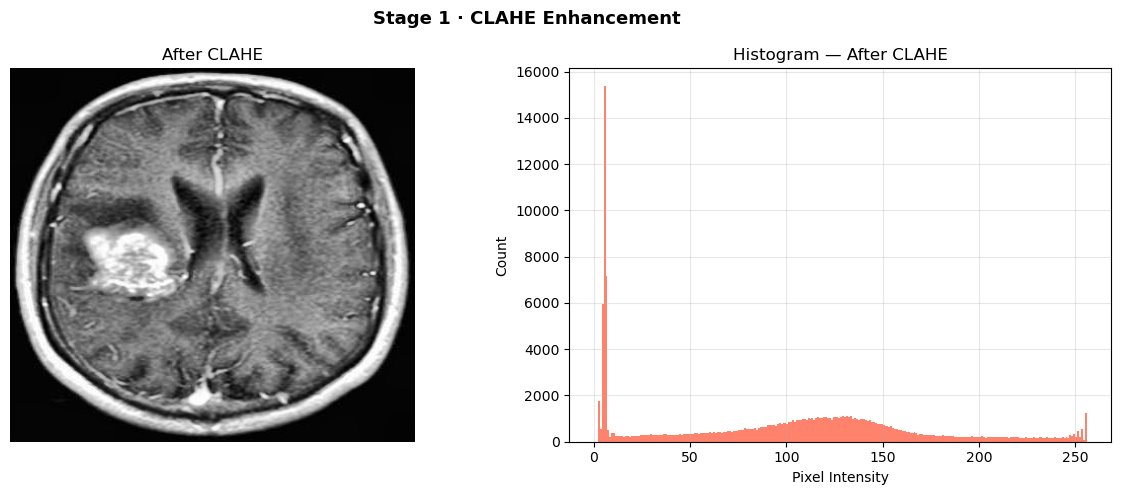

In [17]:
# Cell 3 — Stage 1 : CLAHE Enhancement

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CLAHE Enhanced Image
axes[0].imshow(gray_clahe, cmap="gray")
axes[0].set_title("After CLAHE")
axes[0].axis("off")

# CLAHE Histogram Only
axes[1].hist(
    gray_clahe.ravel(),
    bins=256,
    range=(0, 256),
    color="tomato",
    alpha=0.8
)

axes[1].set_title("Histogram — After CLAHE")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.suptitle("Stage 1 · CLAHE Enhancement", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clahe_with_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# Just keep grayscale:
clahe_result = gray_clahe  # or keep using gray_clahe directly

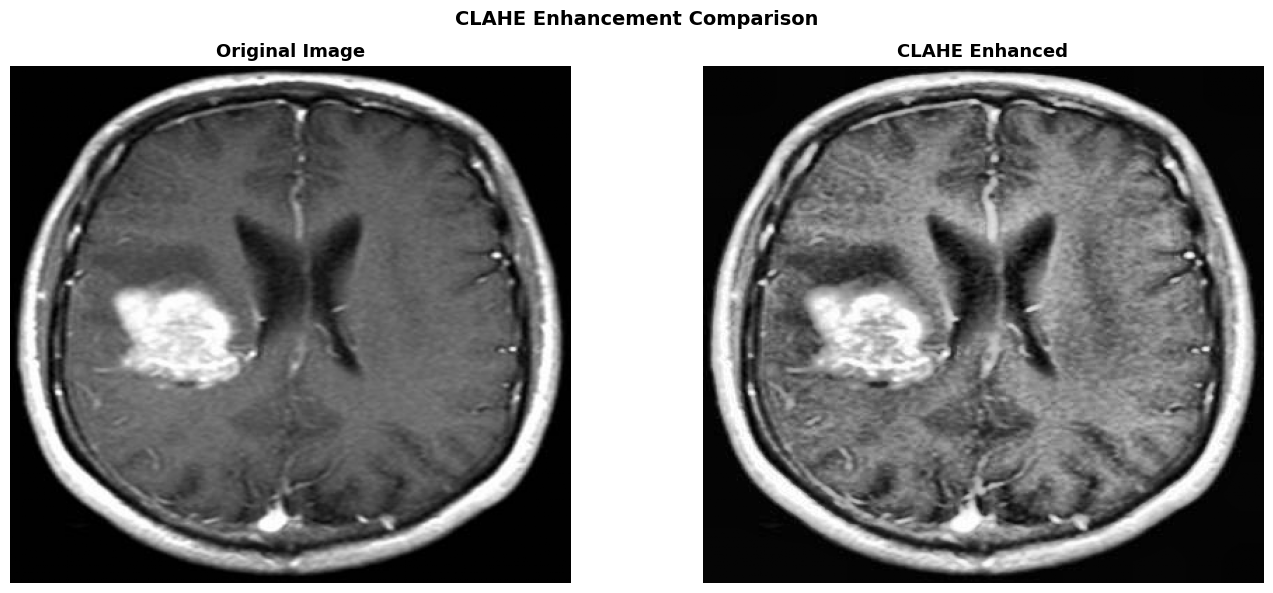

In [18]:
# Plot Original vs CLAHE Enhanced Image
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(gray_clahe, cmap='gray')
axes[1].set_title('CLAHE Enhanced', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('CLAHE Enhancement Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

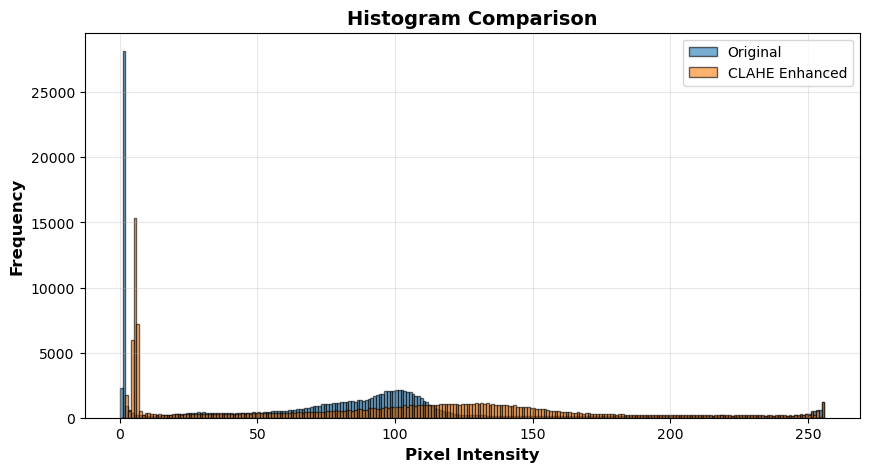

In [19]:
import matplotlib.pyplot as plt

# Histogram comparison
plt.figure(figsize=(10, 5))

bins = 256

plt.hist(gray.ravel(),
         bins=bins,
         range=(0, 256),
         alpha=0.6,
         label='Original',
         edgecolor='black')

plt.hist(gray_clahe.ravel(),
         bins=bins,
         range=(0, 256),
         alpha=0.6,
         label='CLAHE Enhanced',
         edgecolor='black')

plt.xlabel('Pixel Intensity', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Histogram Comparison', fontsize=14, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

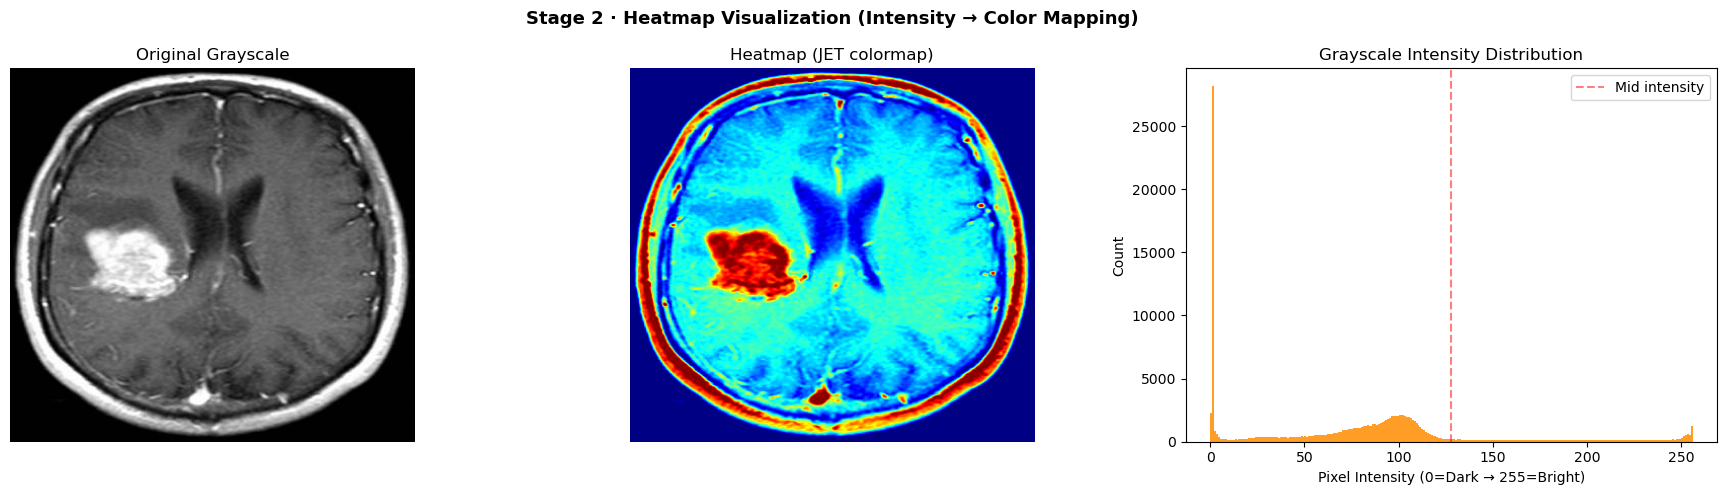

In [20]:
# Cell 4 — Stage 2 : Heatmap (JET colormap) - OPTIMIZED FOR GRAYSCALE INPUT

# Apply JET colormap directly to grayscale
heatmap_bgr = cv2.applyColorMap(gray, cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Show original grayscale (not RGB - since it's grayscale)
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

# Show heatmap
axes[1].imshow(heatmap_rgb)
axes[1].set_title("Heatmap (JET colormap)")
axes[1].axis("off")

# Histogram of original grayscale
axes[2].hist(gray.ravel(), bins=256, range=(0,256), color="darkorange", alpha=0.85)
axes[2].set_title("Grayscale Intensity Distribution")
axes[2].set_xlabel("Pixel Intensity (0=Dark → 255=Bright)")
axes[2].set_ylabel("Count")
axes[2].axvline(x=128, color='red', linestyle='--', alpha=0.5, label='Mid intensity')
axes[2].legend()

plt.suptitle("Stage 2 · Heatmap Visualization (Intensity → Color Mapping)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_with_histogram.png", dpi=300, bbox_inches='tight')
plt.show()


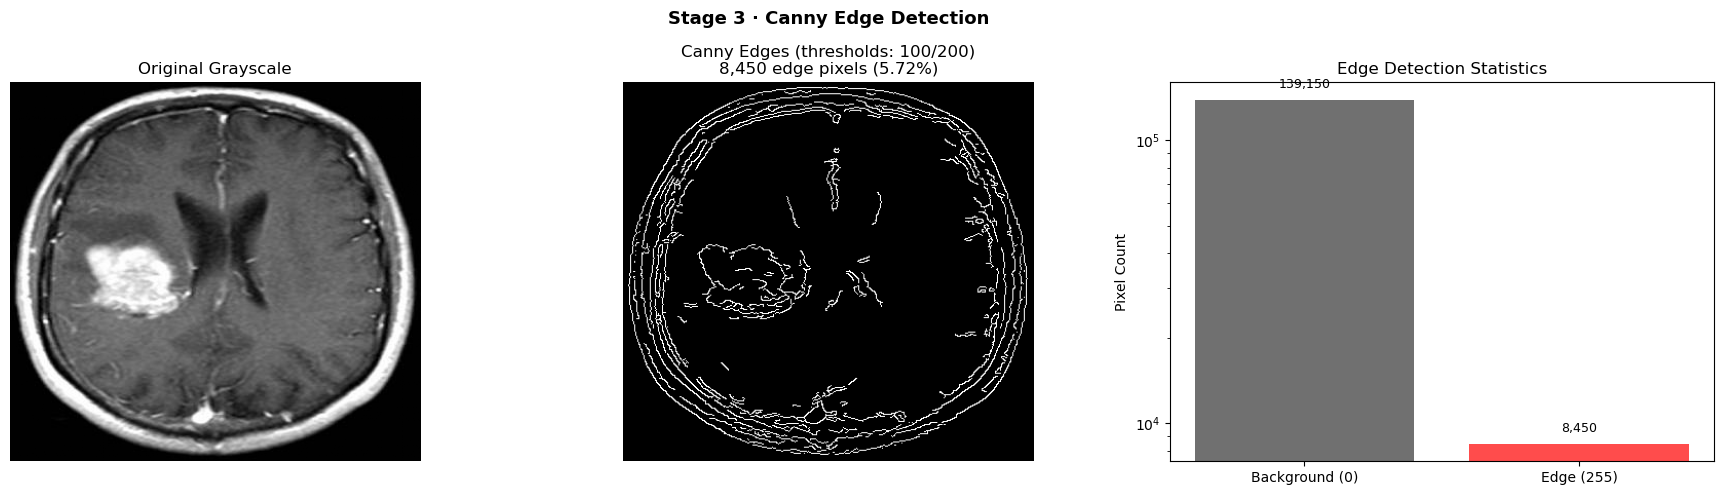

In [21]:
# Cell 5 — Stage 3 : Canny Edge Detection - OPTIMIZED

edges = cv2.Canny(gray, 100, 200)

# Count edge pixels correctly
edge_pixel_count = np.sum(edges == 255)
background_pixels = np.sum(edges == 0)
edge_percentage = (edge_pixel_count / edges.size) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original grayscale (not RGB)
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

# Edge map - stay grayscale!
axes[1].imshow(edges, cmap="gray")
axes[1].set_title(f"Canny Edges (thresholds: 100/200)\n{edge_pixel_count:,} edge pixels ({edge_percentage:.2f}%)")
axes[1].axis("off")

# Edge pixel distribution
axes[2].bar(["Background (0)", "Edge (255)"], 
            [background_pixels, edge_pixel_count],
            color=["#333333", "red"], alpha=0.7)
axes[2].set_title("Edge Detection Statistics")
axes[2].set_ylabel("Pixel Count")
axes[2].set_yscale('log')  # Log scale since backgrounds dominate
for i, v in enumerate([background_pixels, edge_pixel_count]):
    axes[2].text(i, v + v*0.1, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Stage 3 · Canny Edge Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("canny_edge_detection.png", dpi=300, bbox_inches='tight')
plt.show()


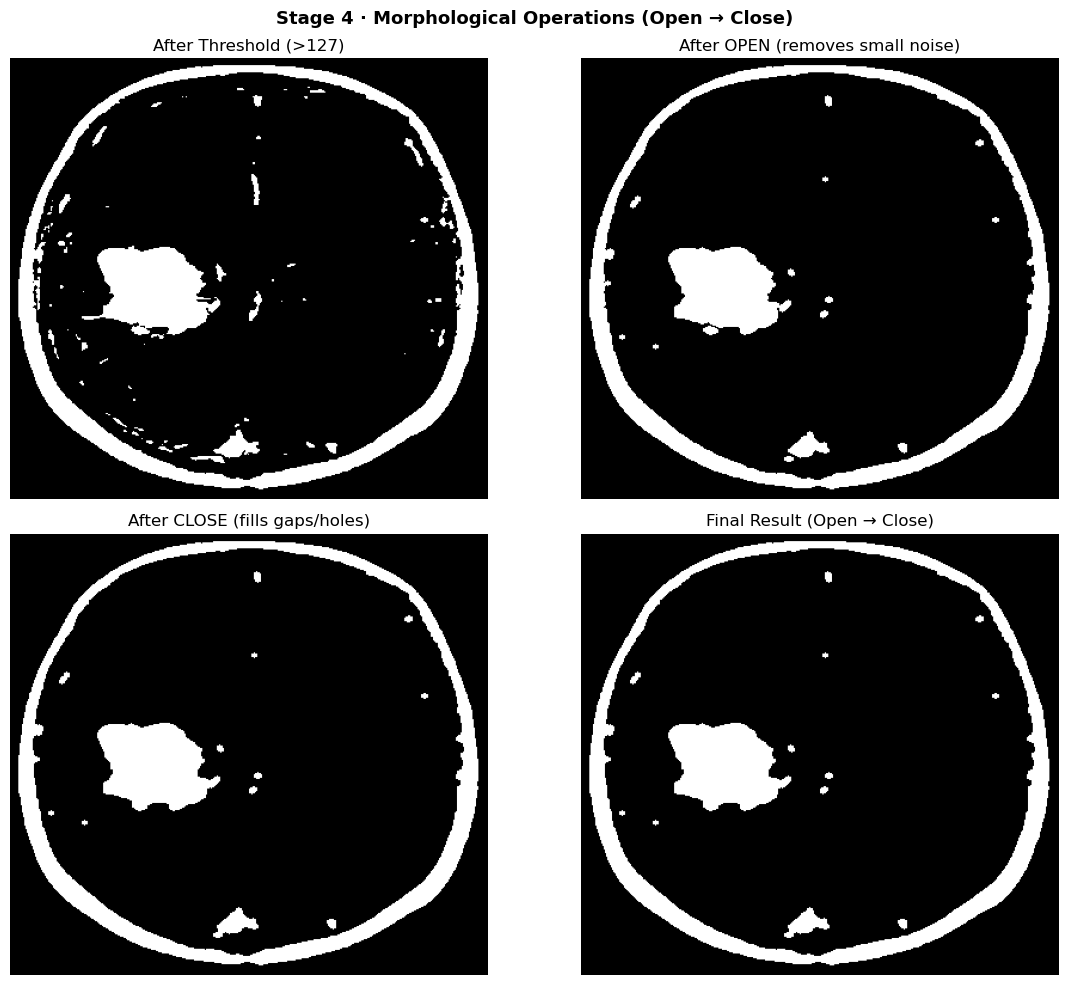

In [22]:
# Cell 6 — Stage 4 : Morphological Open → Close (Optimized)
_, thresh_morph = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
after_open = cv2.morphologyEx(thresh_morph, cv2.MORPH_OPEN, kernel)
after_close = cv2.morphologyEx(after_open, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-Left: After Threshold
axes[0, 0].imshow(thresh_morph, cmap="gray")
axes[0, 0].set_title("After Threshold (>127)")
axes[0, 0].axis("off")

# Top-Right: After OPEN (removes noise)
axes[0, 1].imshow(after_open, cmap="gray")
axes[0, 1].set_title("After OPEN (removes small noise)")
axes[0, 1].axis("off")

# Bottom-Left: After CLOSE (fills holes)
axes[1, 0].imshow(after_close, cmap="gray")
axes[1, 0].set_title("After CLOSE (fills gaps/holes)")
axes[1, 0].axis("off")

# Bottom-Right: Final Result
axes[1, 1].imshow(after_close, cmap="gray")
axes[1, 1].set_title("Final Result (Open → Close)")
axes[1, 1].axis("off")

plt.suptitle("Stage 4 · Morphological Operations (Open → Close)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("morphological_open_close.png", dpi=300, bbox_inches='tight')
plt.show()

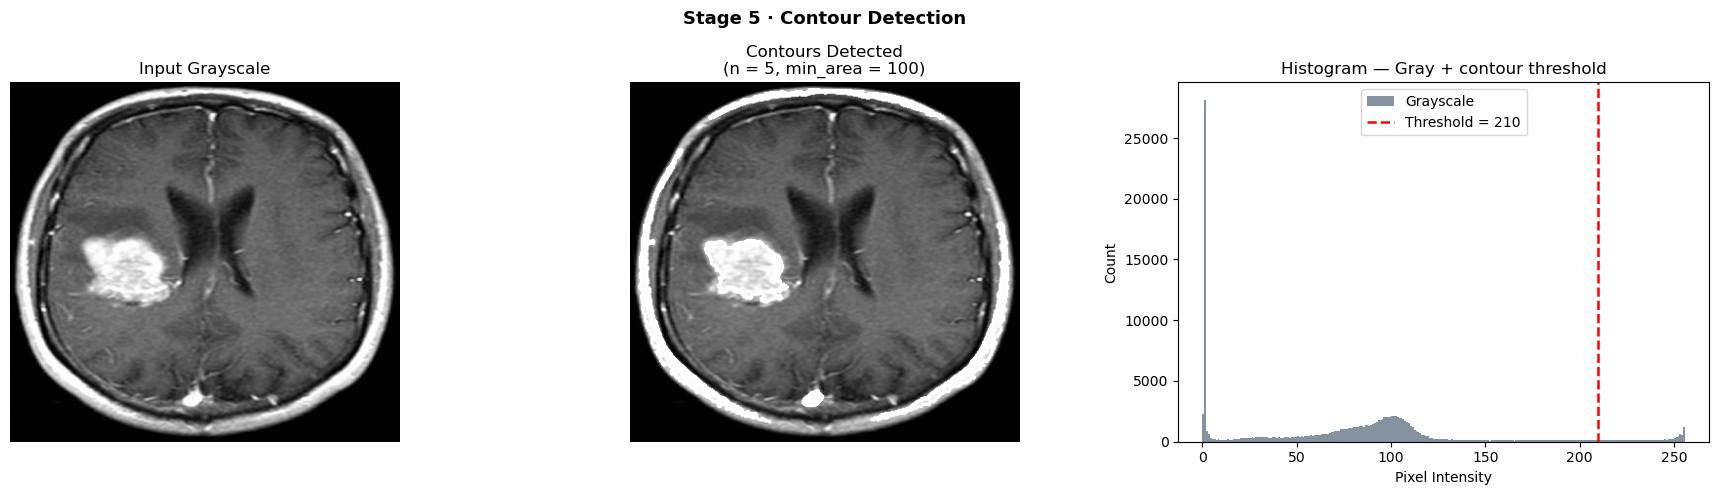

Total contours found : 5


In [23]:
# Cell 7 — Stage 5 : Contour Detection (Pure Grayscale)
_, thresh_cnt   = cv2.threshold(gray, 210, 255, cv2.THRESH_BINARY)
contours, _     = cv2.findContours(thresh_cnt, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
filtered        = [c for c in contours_sorted if cv2.contourArea(c) > 100]

# Create grayscale canvas for contours
contour_canvas = gray.copy()
cv2.drawContours(contour_canvas, filtered, -1, 255, 2)  # 255 = white

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Input Grayscale")
axes[0].axis("off")

axes[1].imshow(contour_canvas, cmap="gray")
axes[1].set_title(f"Contours Detected\n(n = {len(filtered)}, min_area = 100)")
axes[1].axis("off")

axes[2].hist(gray.ravel(), bins=256, range=(0,256), color="slategray", alpha=0.85, label="Grayscale")
axes[2].axvline(210, color="red", linewidth=1.8, linestyle="--", label="Threshold = 210")
axes[2].set_title("Histogram — Gray + contour threshold")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("Stage 5 · Contour Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("contour_detection.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Total contours found : {len(filtered)}")

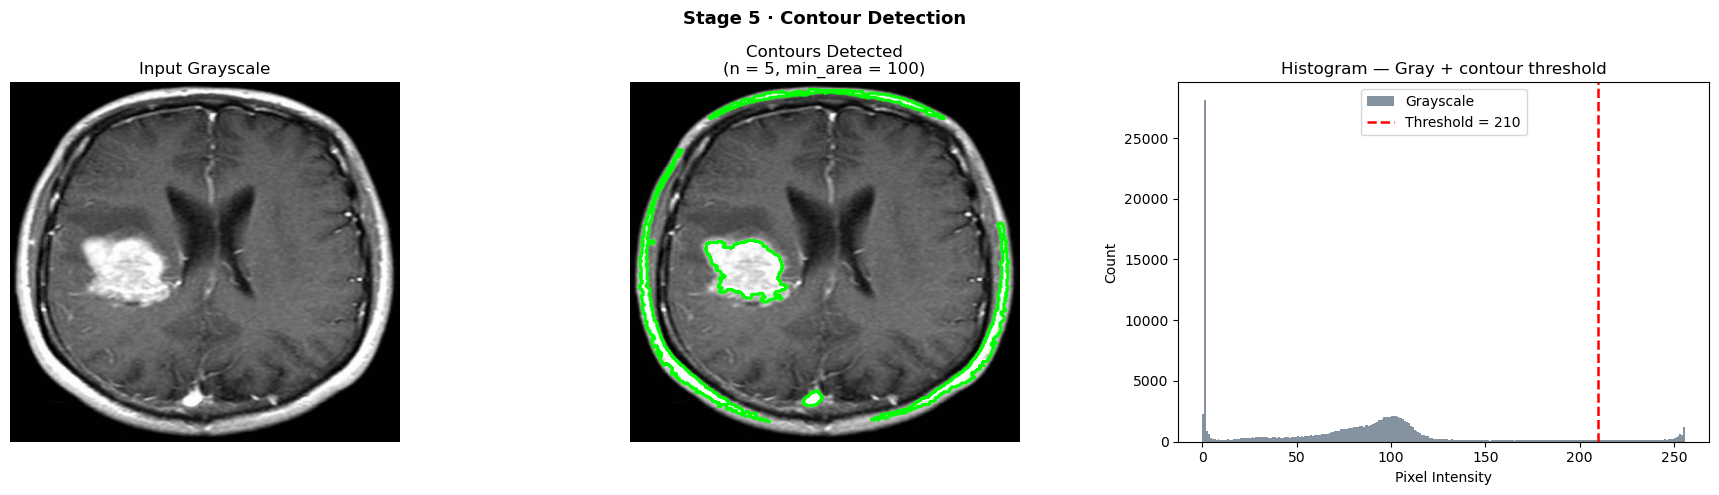

Total contours found : 5


In [24]:
# Cell 7 — Stage 5 : Contour Detection (Grayscale + Visible Contours)
_, thresh_cnt   = cv2.threshold(gray, 210, 255, cv2.THRESH_BINARY)
contours, _     = cv2.findContours(thresh_cnt, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
filtered        = [c for c in contours_sorted if cv2.contourArea(c) > 100]

# Convert to BGR just for drawing colored contours (minimal conversion)
contour_canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_canvas, filtered, -1, (0, 255, 0), 2)  # Green contours

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Input Grayscale")
axes[0].axis("off")

axes[1].imshow(contour_canvas)  # RGB image with green contours
axes[1].set_title(f"Contours Detected\n(n = {len(filtered)}, min_area = 100)")
axes[1].axis("off")

axes[2].hist(gray.ravel(), bins=256, range=(0,256), color="slategray", alpha=0.85, label="Grayscale")
axes[2].axvline(210, color="red", linewidth=1.8, linestyle="--", label="Threshold = 210")
axes[2].set_title("Histogram — Gray + contour threshold")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("Stage 5 · Contour Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("contour_detection.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Total contours found : {len(filtered)}")

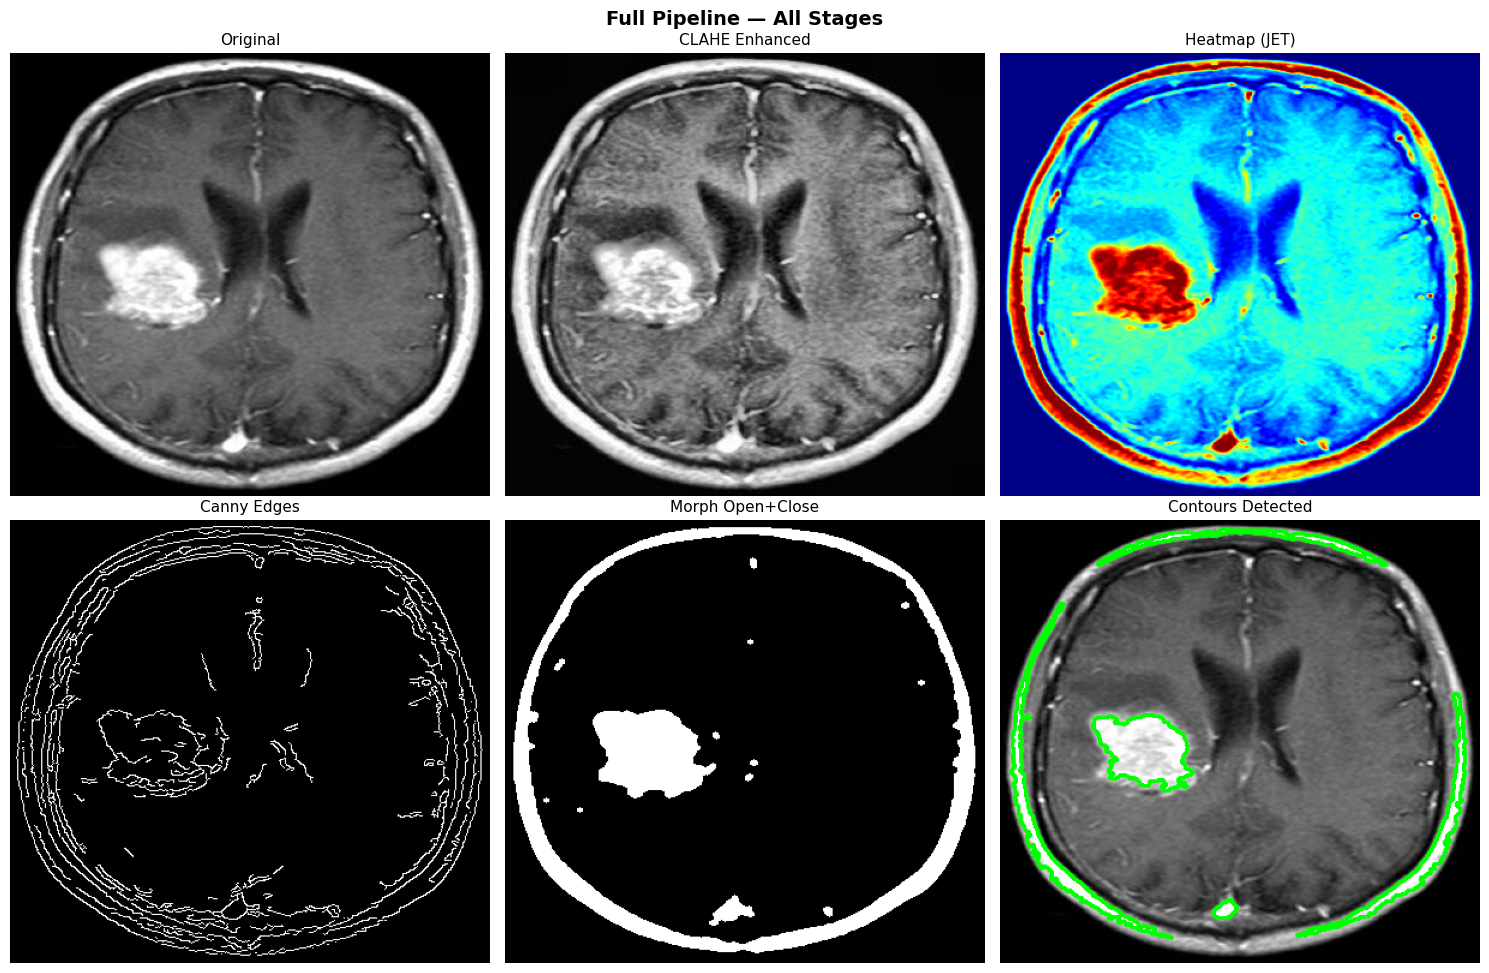

In [25]:
# Cell 8 — Summary Grid : All Stages Side-by-Side (Grayscale Only)

# Prepare all stages in consistent format
all_stages = [
    ("Original", gray, "gray"),  # (title, image, colormap)
    ("CLAHE Enhanced", gray_clahe, "gray"),
    ("Heatmap (JET)", heatmap_rgb, None),  # Heatmap is already RGB
    ("Canny Edges", edges, "gray"),
    ("Morph Open+Close", after_close, "gray"),
    ("Contours Detected", contour_canvas, None),  # Contours canvas (RGB with green lines)
]

cols = 3
rows = int(np.ceil(len(all_stages) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

for ax, (title, img, cmap) in zip(axes.flat, all_stages):
    if cmap:
        ax.imshow(img, cmap=cmap)
    else:
        ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

# Hide any unused subplots
for ax in list(axes.flat)[len(all_stages):]:
    ax.set_visible(False)

plt.suptitle("Full Pipeline — All Stages", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("full_pipeline_summary.png", dpi=300, bbox_inches='tight')
plt.show()